# 黑市数据分析

在定性分析章节讲过：黑市 和 策略房/商店房 的区别是，黑市会无视前置策略来获得策略，策略池不同。

# 带满光系一阶强化，进入黑市，观测分布情况

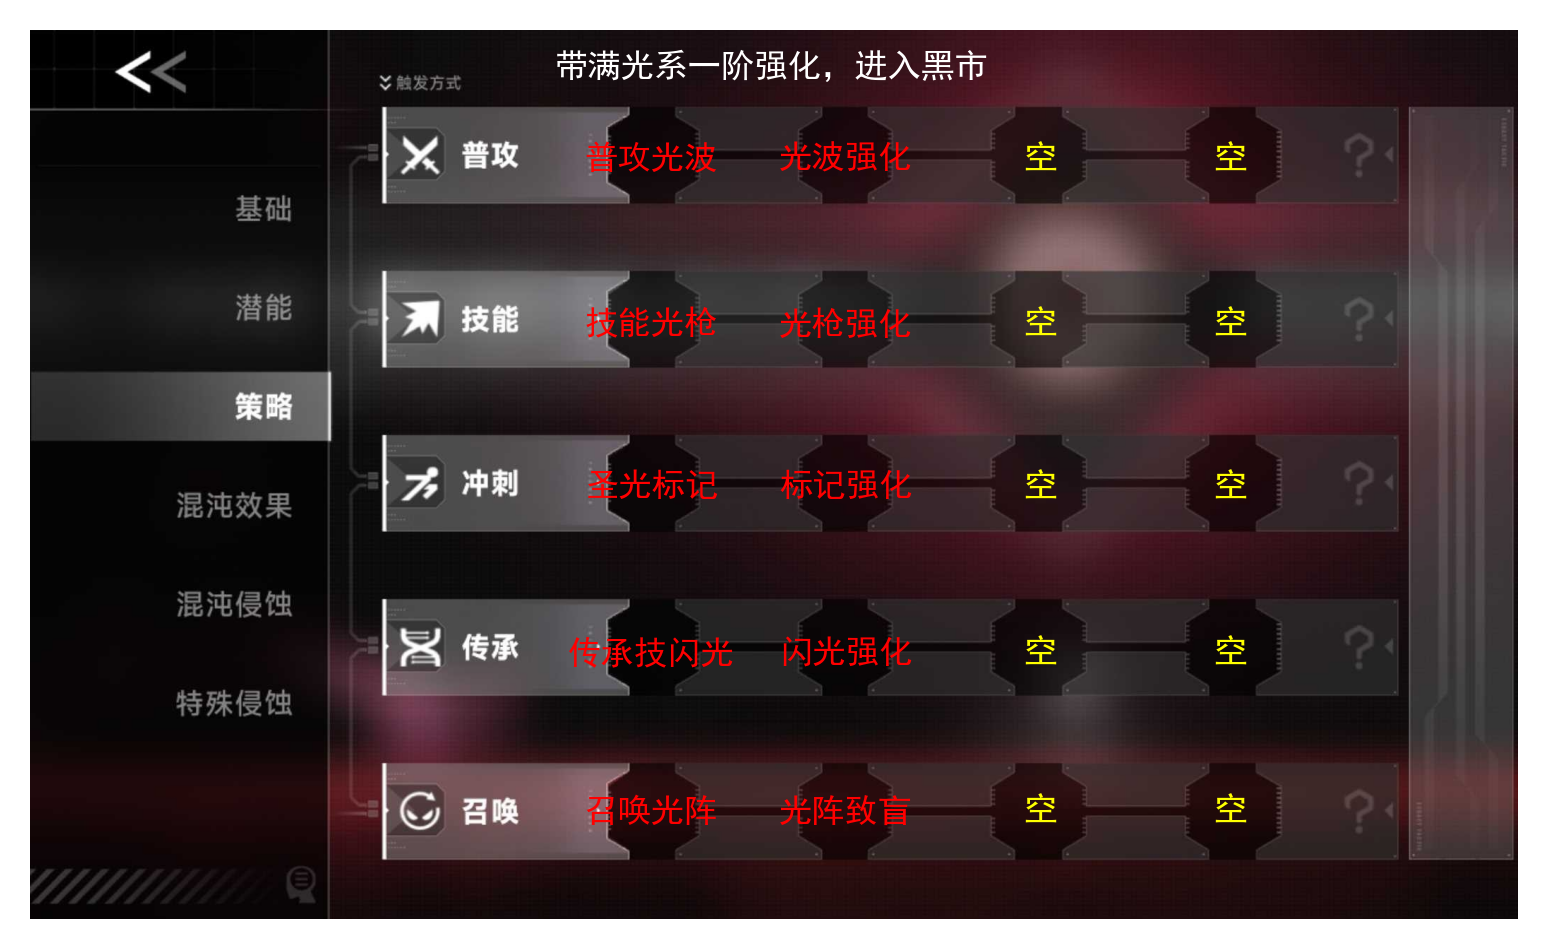

由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机


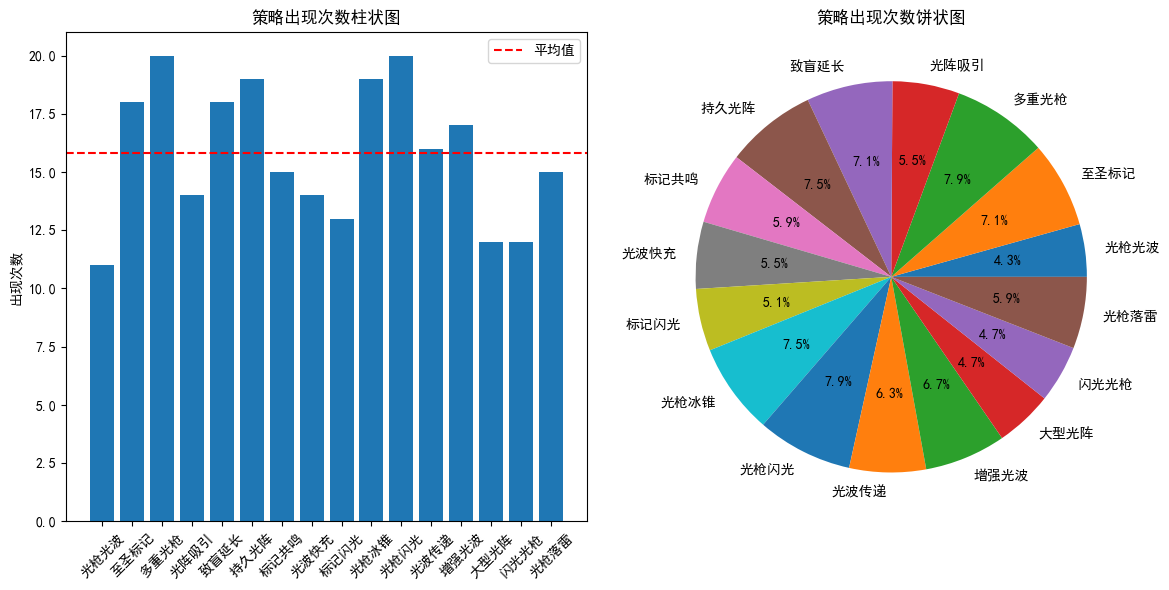

卡方统计量: 8.50197628458498, p 值: 0.902086825781913
数据可能来自均匀分布或离散型概率分布


In [1]:
from collections import Counter
import utils

current_strategies, strategies = utils.parse_file('data/黑市房/黑市_全光2阶.txt')
utils.draw_status("带满光系一阶强化，进入黑市", current_strategies)
print("由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机")
strategies = list([x[0] for x in strategies])
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 带满光系基础策略，进入黑市，观测分布情况

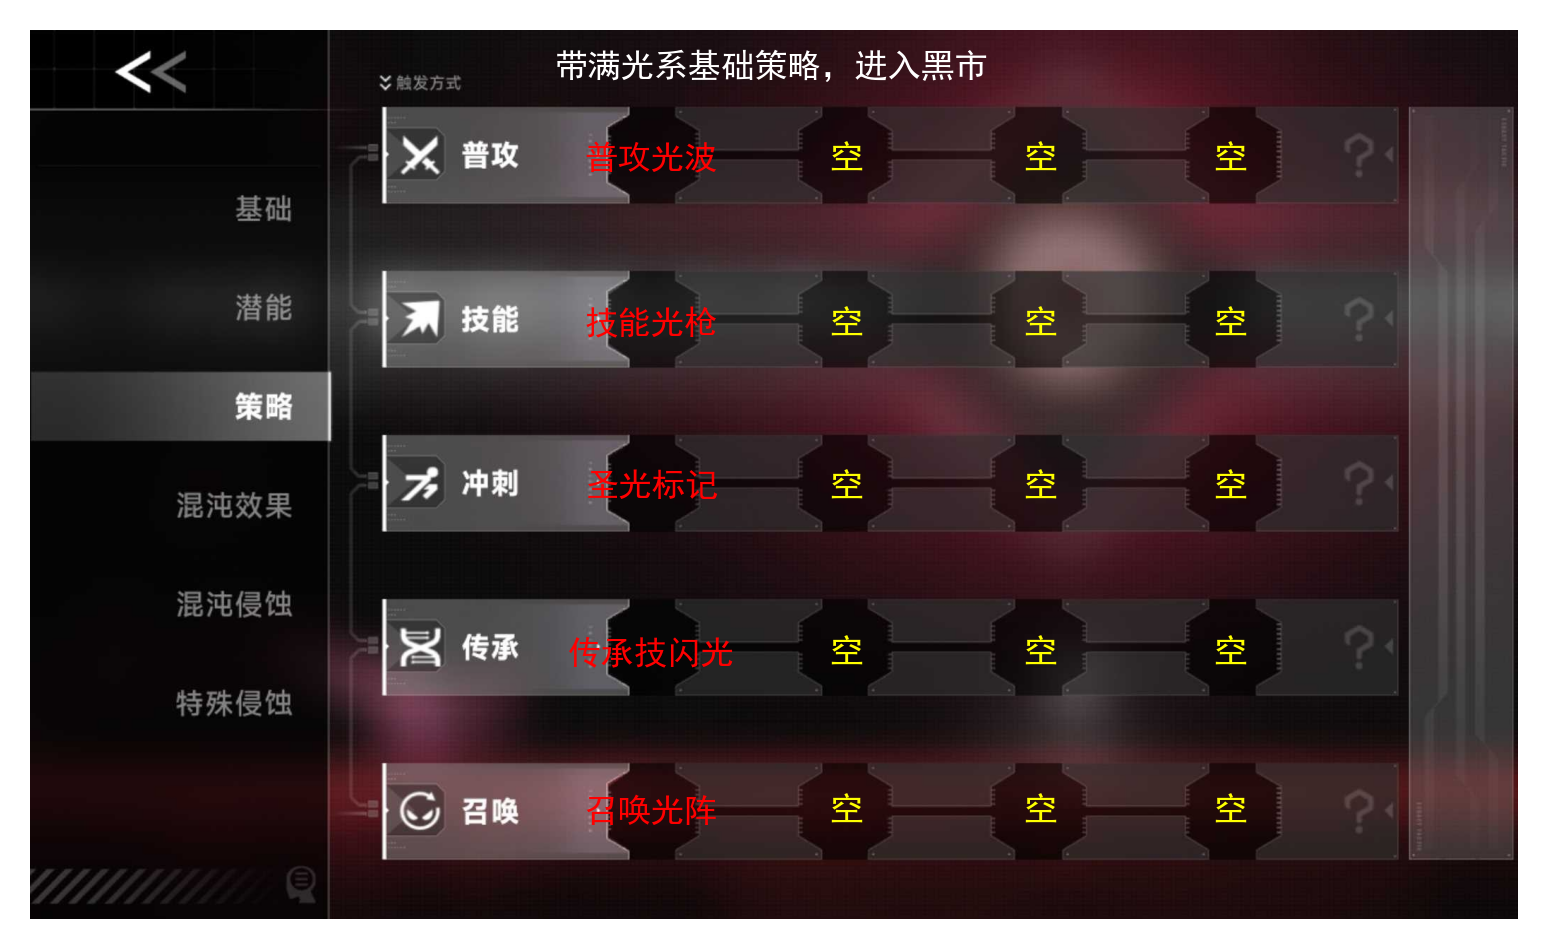

由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机


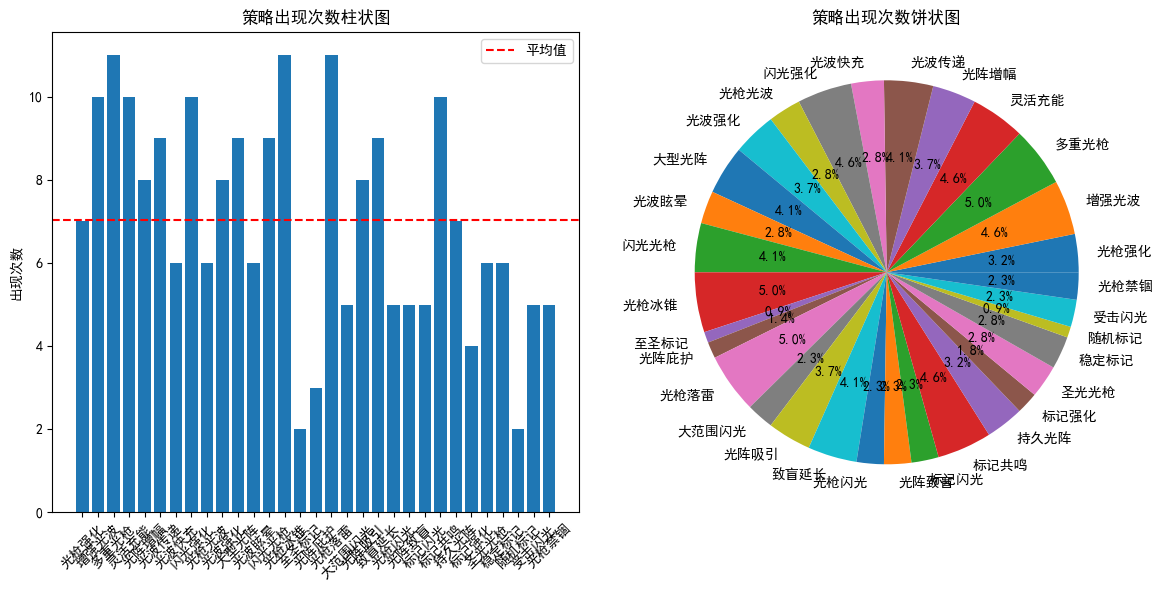

卡方统计量: 29.431192660550465, p 值: 0.49503977868713345
数据可能来自均匀分布或离散型概率分布


In [2]:
current_strategies, strategies = utils.parse_file('data/黑市房/黑市_全光1阶.txt')
utils.draw_status("带满光系基础策略，进入黑市", current_strategies)
print("由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机")
strategies = list([x[0] for x in strategies])
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 全空，进入黑市，观测分布情况

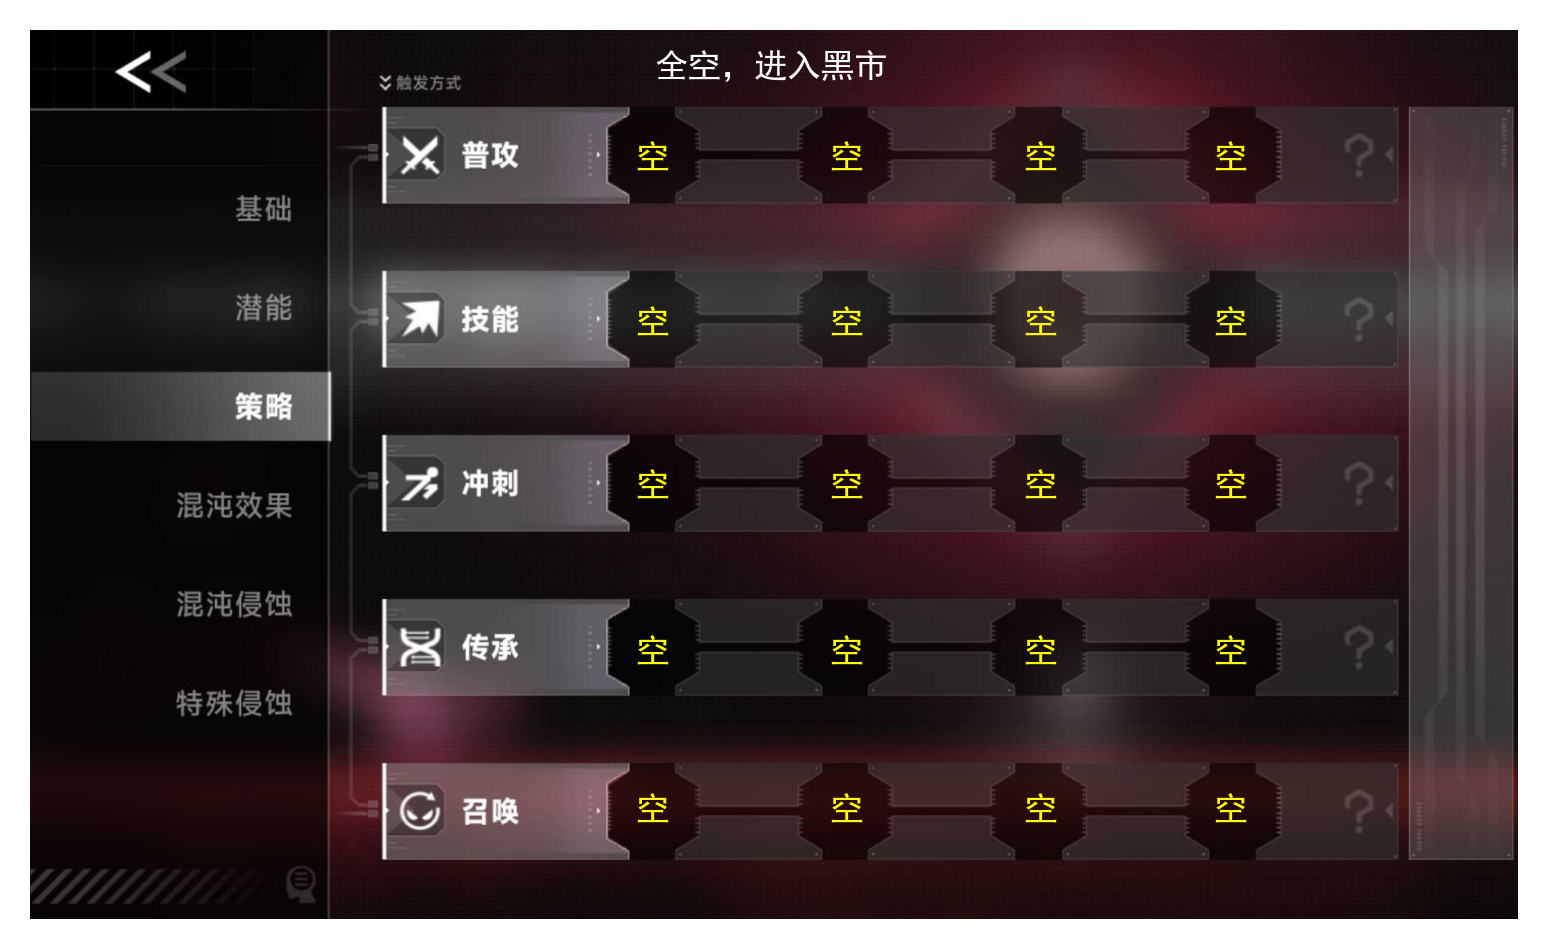

由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机


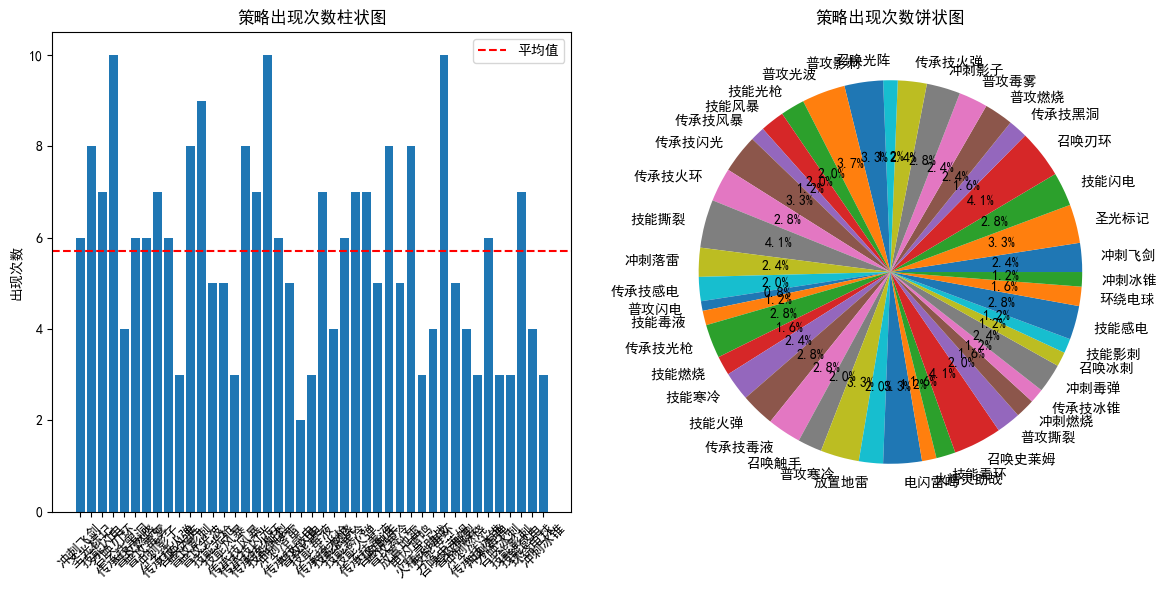

卡方统计量: 34.02439024390243, p 值: 0.8046362392026183
数据可能来自均匀分布或离散型概率分布


In [3]:
current_strategies, strategies = utils.parse_file('data/黑市房/黑市_全空.txt')
utils.draw_status("全空，进入黑市", current_strategies)
print("由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机")
strategies = list([x[0] for x in strategies])
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 夹杂着测试，进入黑市，观测分布情况

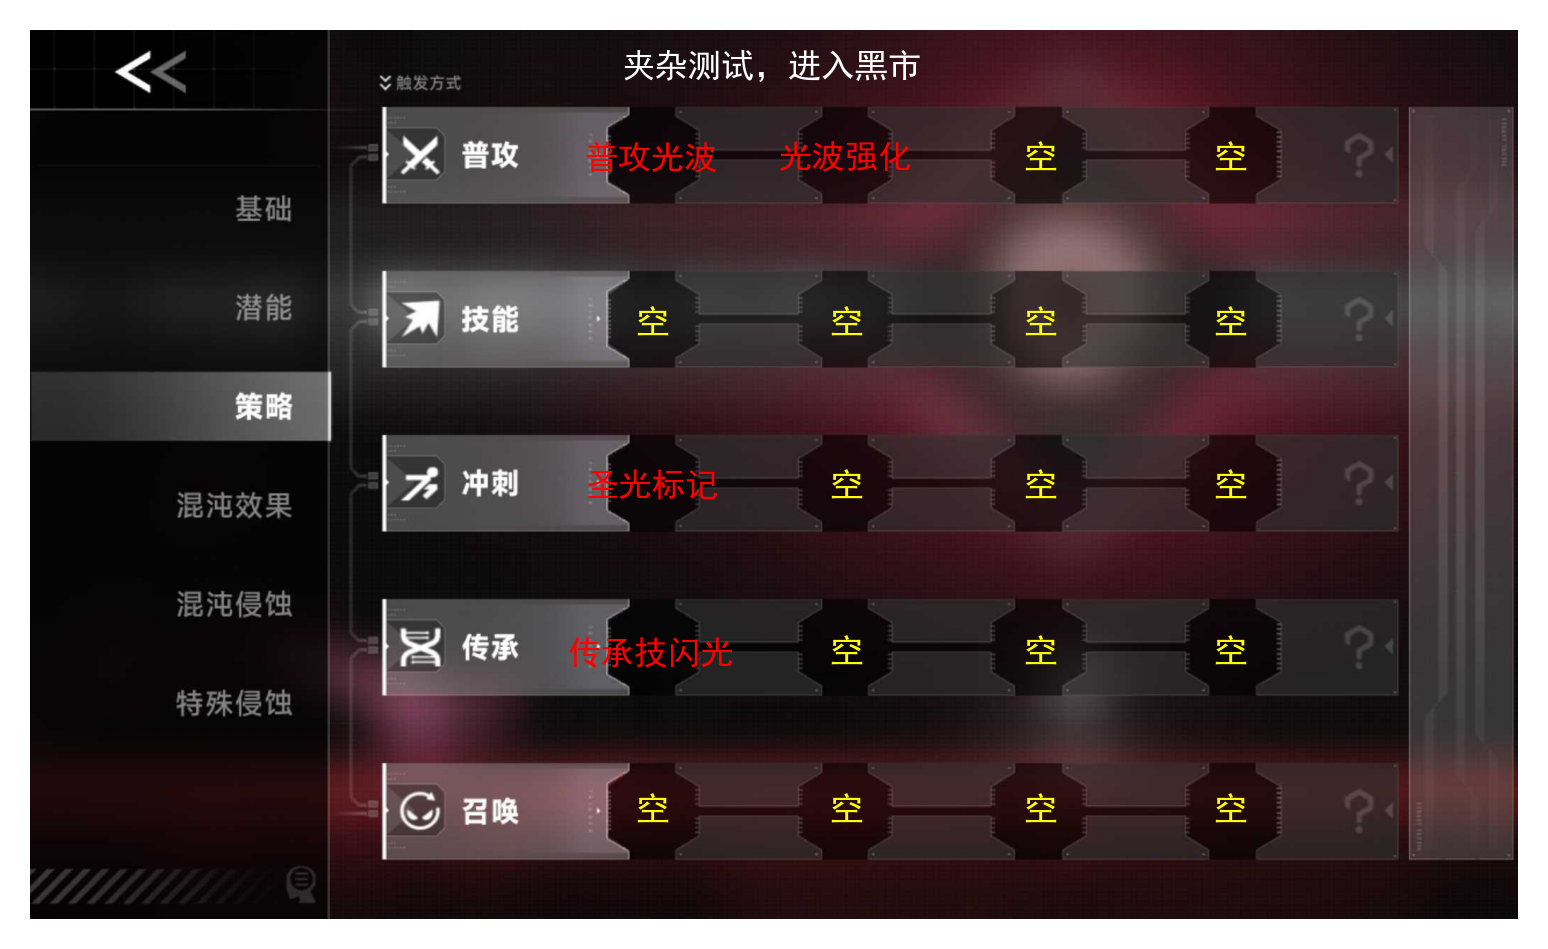

由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机


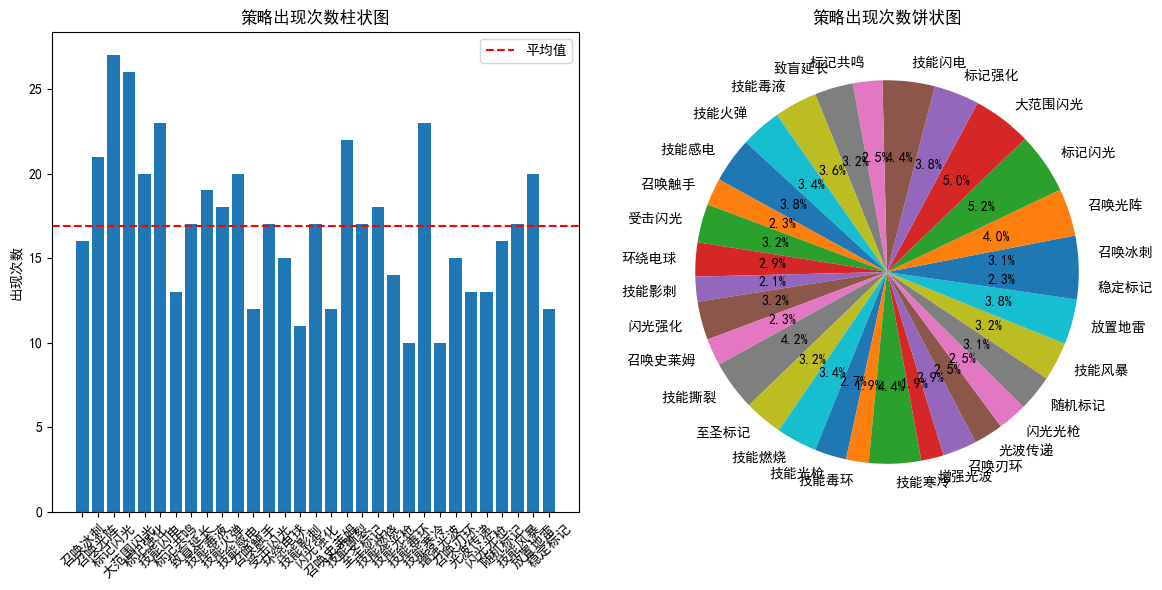

卡方统计量: 35.656488549618324, p 值: 0.21953877402528346
数据可能来自均匀分布或离散型概率分布


In [4]:
current_strategies, strategies = utils.parse_file('data/黑市房/黑市_2个基础2个一阶1个二阶.txt')
utils.draw_status("夹杂测试，进入黑市", current_strategies)
print("由于第N轮随机的结果会影响到第N+1轮的池子，因此先只观测第一轮随机")
strategies = list([x[0] for x in strategies])
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 目前的数据支持了：第一抽的概率是均匀分布的

# 推导：黑市五连抽可用**马尔科夫链模型**来描述

第一抽的结果会影响到第二抽，例如全空的场景下，第一抽必然是基础策略，第二抽才会出现该派系对应的高级策略。

例如如果第一抽是 \[普攻光波\]，那么第二抽会 <font color='red'>移除普攻位所有其他策略，加入光波的 一阶/二阶/单激活红 </font>

case1：全空，第一抽获得了 \[普攻光波\]，第二抽的池子是A。

case2：只带有\[普攻光波\]，进入黑市，第一抽的池子是B。

根据**大量的经验和实践**告诉我们，这个A和B是一模一样的，A和B的概率分布也是一模一样的。

> 马尔科夫链是一种具有 **马尔科夫性（无记忆性）** 的随机过程，由俄罗斯数学家安德烈・马尔可夫（Andrey Markov）于 1906 年提出。其核心思想是：系统在未来的状态仅取决于当前状态，与过去的历史状态无关。

# 第2345抽的难点

假设采集了100组数据，其中可能只有5组第一抽是 \[普攻光波\]，而这5组数据完全无法支撑概率论的相关特性。

由于单次采样耗时较长，很难有足够数量的样本支持统计分析。

新思路：
- **根据分类处理数据，例如按照触发位、按照等级、按照属性、按照派系**
- **只分析已经带有5个基础策略的场景，就不会再出现基础策略，从而防止大规模的策略加入和移除**

# 使用带满光系一阶强化的场景，研究第二、三、四、五抽

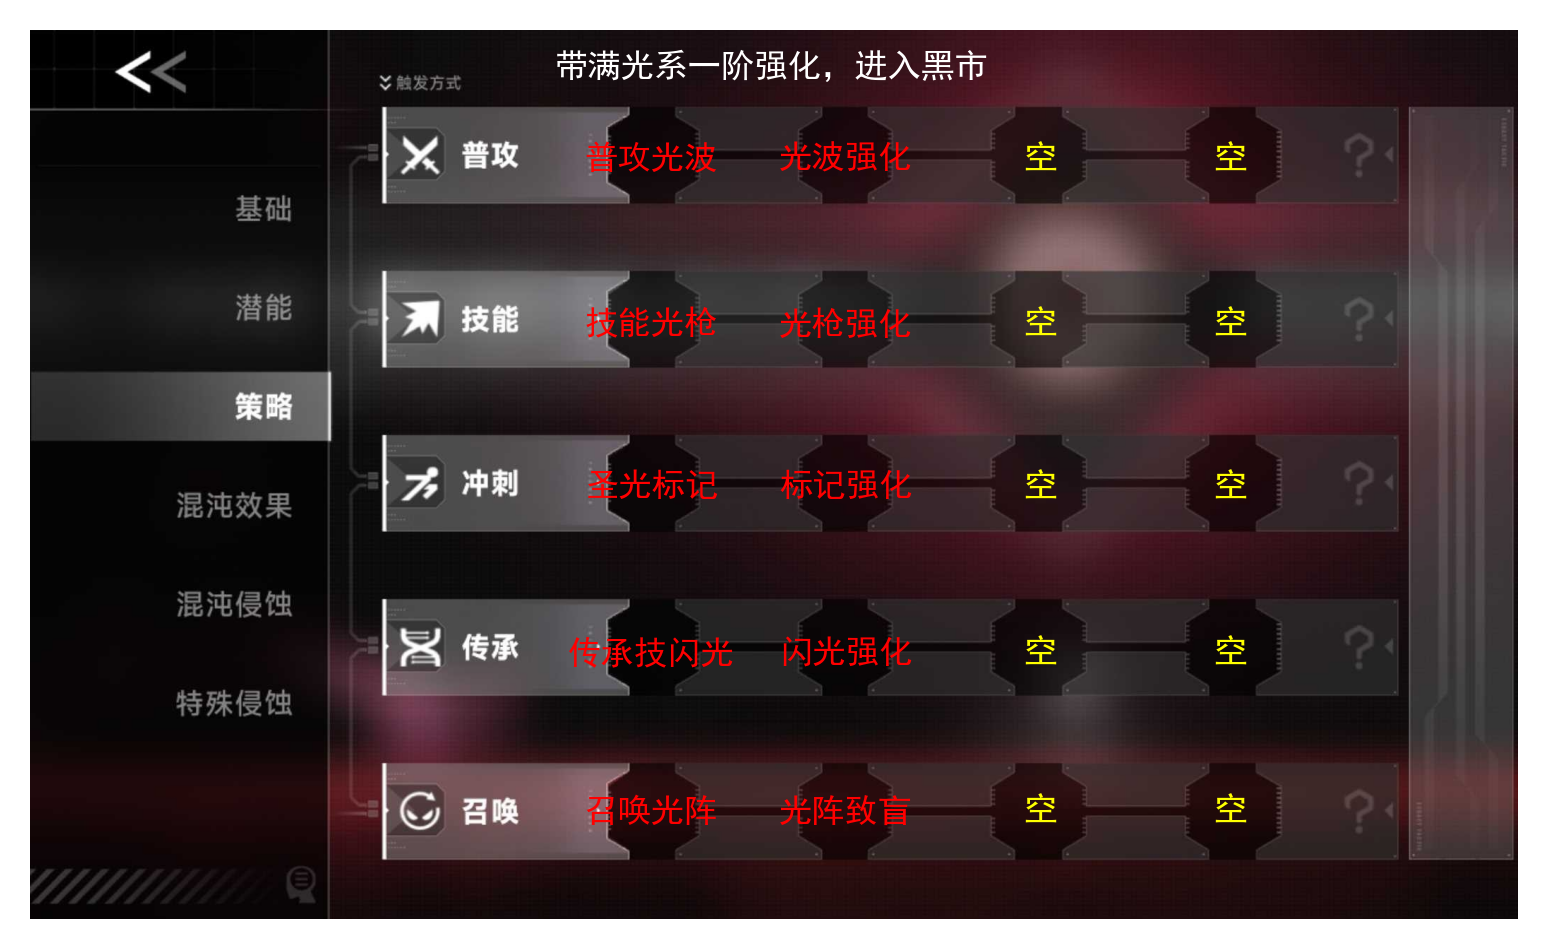

In [5]:
current_strategies, strategies = utils.parse_file('data/黑市房/黑市_全光2阶.txt')
utils.draw_status("带满光系一阶强化，进入黑市", current_strategies)

将池内的所有二阶强化和红策略分类，如下：

```python
group_names = [
    "增强光波",
    "光波传递, 至圣标记, 光波快充",
    "多重光枪",
    "光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷",
    "标记共鸣",
    "标记闪光",
    "致盲延长",
    "闪光光枪, 持久光阵",
    "大型光阵",
    "光阵吸引"
]
```

每一抽从 group 中抽取（带权重），抽取后再也不放回，因此**从复杂的马尔科夫链模型退化为较为简单的高中概率知识**，即：口袋中有10个乒乓球，每次拿1个出来，进行5次，且这些乒乓球的权重有差异。

# 10个策略槽，第1轮抽取和验证

In [6]:
group_names = [
    "增强光波",
    "光波传递, 至圣标记, 光波快充",
    "多重光枪",
    "光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷",
    "标记共鸣",
    "标记闪光",
    "致盲延长",
    "闪光光枪, 持久光阵",
    "大型光阵",
    "光阵吸引"
]
weights = [1, 3, 1, 4, 1, 1, 1, 2, 1, 1]  # 各Group的权重（元素数量）
total = sum(weights)

# 第1轮概率计算
round_probs = [w / sum(weights) for w in weights]
# 第1轮分组化的统计频次
round1_cnt = utils.to_groups([x[0] for x in strategies], group_names)
utils.print_probs(group_names, 1, round_probs)
chi2, p = utils.test_uniform_distribution(round1_cnt, round_probs)

第1轮理论概率分布：
Group[增强光波]：0.062500
Group[光波传递, 至圣标记, 光波快充]：0.187500
Group[多重光枪]：0.062500
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.250000
Group[标记共鸣]：0.062500
Group[标记闪光]：0.062500
Group[致盲延长]：0.062500
Group[闪光光枪, 持久光阵]：0.125000
Group[大型光阵]：0.062500
Group[光阵吸引]：0.062500

卡方统计量: 3.2371541501976284, p 值: 0.9541456587226101
数据可能来自均匀分布或离散型概率分布


# 10个策略槽，第2轮抽取和验证

In [7]:
# 第2轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        prob = (weights[i] / total) * (weights[j] / remaining_after_first)
        round_probs[j] += prob
# 第2轮分组化的统计频次
round_cnt = utils.to_groups([x[1] for x in strategies], group_names)
utils.print_probs(group_names, 2, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第2轮理论概率分布：
Group[增强光波]：0.069185
Group[光波传递, 至圣标记, 光波快充]：0.176786
Group[多重光枪]：0.069185
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.210073
Group[标记共鸣]：0.069185
Group[标记闪光]：0.069185
Group[致盲延长]：0.069185
Group[闪光光枪, 持久光阵]：0.128846
Group[大型光阵]：0.069185
Group[光阵吸引]：0.069185

卡方统计量: 4.420938787066763, p 值: 0.8815914146568795
数据可能来自均匀分布或离散型概率分布


# 10个策略槽，第3轮抽取和验证

In [8]:
# 第3轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        remaining_after_second = remaining_after_first - weights[j]
        for k in range(len(weights)):
            if k == i or k == j:
                continue
            prob = (weights[i] / total) * (weights[j] / remaining_after_first) * (weights[k] / remaining_after_second)
            round_probs[k] += prob
# 第3轮分组化的统计频次
round_cnt = utils.to_groups([x[2] for x in strategies], group_names)
utils.print_probs(group_names, 3, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第3轮理论概率分布：
Group[增强光波]：0.076962
Group[光波传递, 至圣标记, 光波快充]：0.160190
Group[多重光枪]：0.076962
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.170230
Group[标记共鸣]：0.076962
Group[标记闪光]：0.076962
Group[致盲延长]：0.076962
Group[闪光光枪, 持久光阵]：0.130847
Group[大型光阵]：0.076962
Group[光阵吸引]：0.076962

卡方统计量: 2.666119740228179, p 值: 0.9760771855257884
数据可能来自均匀分布或离散型概率分布


# 10个策略槽，第4轮抽取和验证


In [9]:
# 第4轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        remaining_after_second = remaining_after_first - weights[j]
        for k in range(len(weights)):
            if k == i or k == j:
                continue
            remaining_after_third = remaining_after_second - weights[k]
            for l in range(len(weights)):
                if l == i or l == j or l == k:
                    continue
                prob = (weights[i] / total) * (weights[j] / remaining_after_first) * (
                        weights[k] / remaining_after_second) * (weights[l] / remaining_after_third)
                round_probs[l] += prob
# 第4轮分组化的统计频次
round_cnt = utils.to_groups([x[3] for x in strategies], group_names)
utils.print_probs(group_names, 4, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第4轮理论概率分布：
Group[增强光波]：0.085709
Group[光波传递, 至圣标记, 光波快充]：0.138928
Group[多重光枪]：0.085709
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.131935
Group[标记共鸣]：0.085709
Group[标记闪光]：0.085709
Group[致盲延长]：0.085709
Group[闪光光枪, 持久光阵]：0.129176
Group[大型光阵]：0.085709
Group[光阵吸引]：0.085709

卡方统计量: 6.616604368515982, p 值: 0.676966757980652
数据可能来自均匀分布或离散型概率分布


# 10个策略槽，第5轮抽取和验证


In [10]:
# 第5轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        remaining_after_second = remaining_after_first - weights[j]
        for k in range(len(weights)):
            if k == i or k == j:
                continue
            remaining_after_third = remaining_after_second - weights[k]
            for l in range(len(weights)):
                if l == i or l == j or l == k:
                    continue
                remaining_after_fourth = remaining_after_third - weights[l]
                for m in range(len(weights)):
                    if m == i or m == j or m == k or m == l:
                        continue
                    prob = (weights[i] / total) * (weights[j] / remaining_after_first) * (
                            weights[k] / remaining_after_second) * (weights[l] / remaining_after_third) * (
                                   weights[m] / remaining_after_fourth)
                    round_probs[m] += prob
# 第5轮分组化的统计频次
round_cnt = utils.to_groups([x[4] for x in strategies], group_names)
utils.print_probs(group_names, 5, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第5轮理论概率分布：
Group[增强光波]：0.095116
Group[光波传递, 至圣标记, 光波快充]：0.114569
Group[多重光枪]：0.095116
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.096737
Group[标记共鸣]：0.095116
Group[标记闪光]：0.095116
Group[致盲延长]：0.095116
Group[闪光光枪, 持久光阵]：0.122883
Group[大型光阵]：0.095116
Group[光阵吸引]：0.095116

卡方统计量: 15.930619889182687, p 值: 0.06834463774877048
数据可能来自均匀分布或离散型概率分布


# 经过验证，目前可以认为在有10个策略空槽的情况下，每一抽的结果独立，每一抽时所有策略的概率相等

# 扩展范围，在有15个策略空槽的情况下，是否依然遵循？

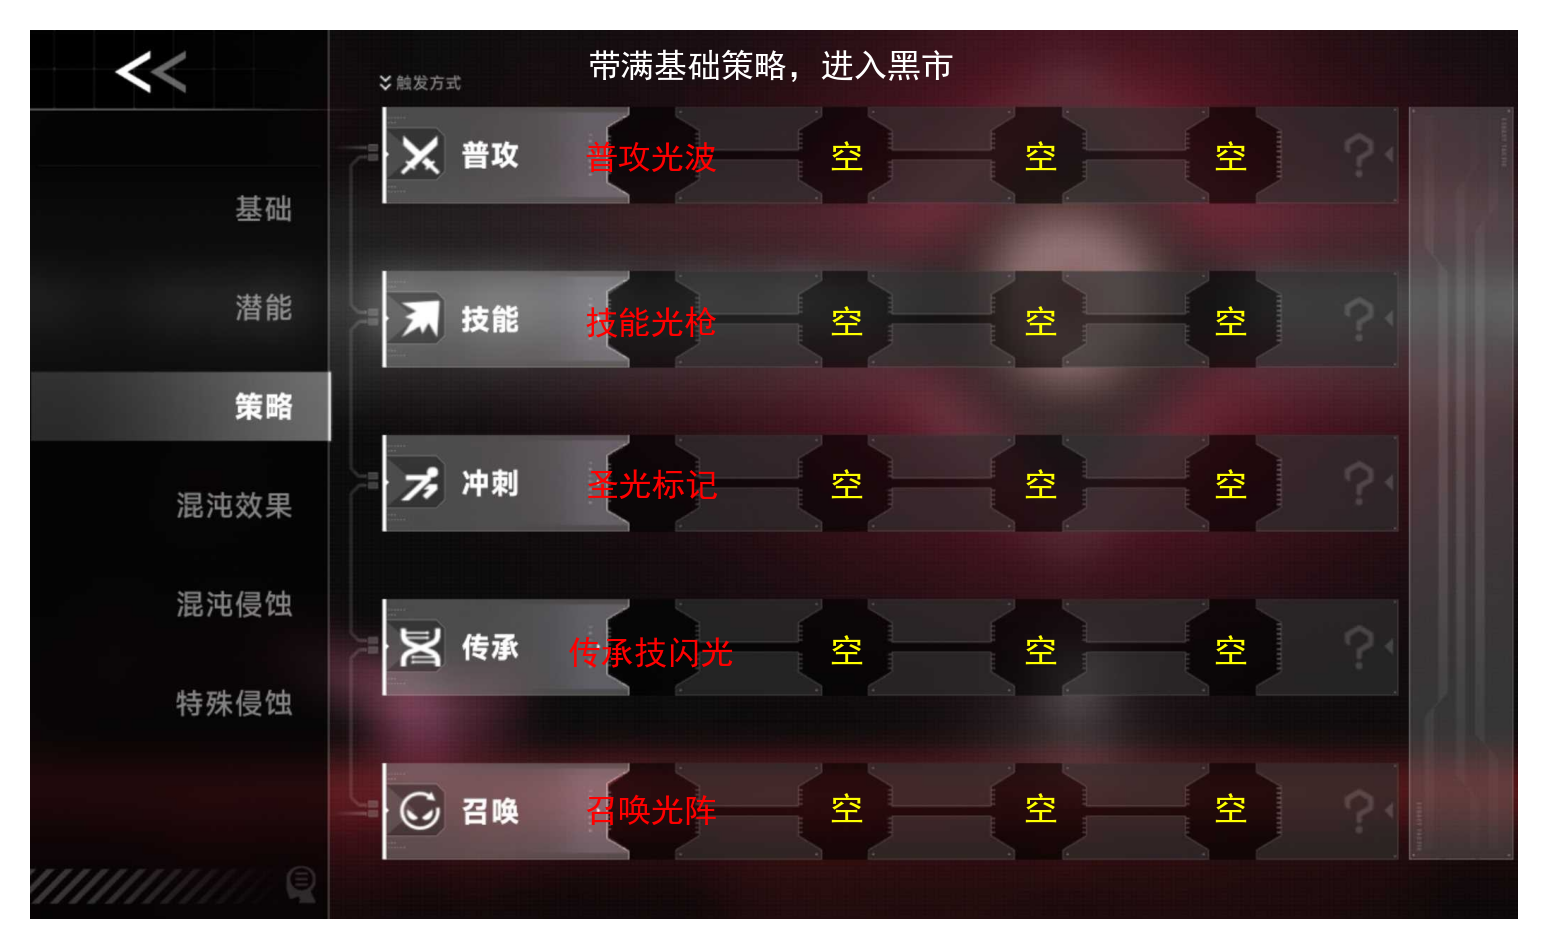

In [11]:
current_strategies, strategies = utils.parse_file('data/黑市房/黑市_全光1阶.txt')
utils.draw_status("带满基础策略，进入黑市", current_strategies)

In [12]:
group_names = [
    "增强光波",
    "光波传递, 至圣标记, 光波快充",
    "多重光枪",
    "光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷",
    "标记共鸣",
    "标记闪光",
    "致盲延长",
    "闪光光枪, 持久光阵",
    "大型光阵",
    "光阵吸引",
    "光波强化, 光波眩晕, 灵活充能",
    "圣光光枪, 光枪禁锢, 光枪强化",
    "稳定标记, 标记强化, 随机标记",
    "闪光强化, 大范围闪光, 受击闪光",
    "光阵致盲, 光阵庇护, 光阵增幅",
]

weights = [1, 3, 1, 4, 1, 1, 1, 2, 1, 1, 3, 3, 3, 3, 3]  # 各Group的权重（元素数量）
total = sum(weights)

# 第1轮概率计算
round_probs = [w / sum(weights) for w in weights]
# 第1轮分组化的统计频次
round1_cnt = utils.to_groups([x[0] for x in strategies], group_names)
utils.print_probs(group_names, 1, round_probs)
chi2, p = utils.test_uniform_distribution(round1_cnt, round_probs)

第1轮理论概率分布：
Group[增强光波]：0.032258
Group[光波传递, 至圣标记, 光波快充]：0.096774
Group[多重光枪]：0.032258
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.129032
Group[标记共鸣]：0.032258
Group[标记闪光]：0.032258
Group[致盲延长]：0.032258
Group[闪光光枪, 持久光阵]：0.064516
Group[大型光阵]：0.032258
Group[光阵吸引]：0.032258
Group[光波强化, 光波眩晕, 灵活充能]：0.096774
Group[圣光光枪, 光枪禁锢, 光枪强化]：0.096774
Group[稳定标记, 标记强化, 随机标记]：0.096774
Group[闪光强化, 大范围闪光, 受击闪光]：0.096774
Group[光阵致盲, 光阵庇护, 光阵增幅]：0.096774

卡方统计量: 14.5355504587156, p 值: 0.4106209149173555
数据可能来自均匀分布或离散型概率分布


In [13]:
# 第2轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        prob = (weights[i] / total) * (weights[j] / remaining_after_first)
        round_probs[j] += prob
# 第2轮分组化的统计频次
round_cnt = utils.to_groups([x[1] for x in strategies], group_names)
utils.print_probs(group_names, 2, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第2轮理论概率分布：
Group[增强光波]：0.034193
Group[光波传递, 至圣标记, 光波快充]：0.095435
Group[多重光枪]：0.034193
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.121956
Group[标记共鸣]：0.034193
Group[标记闪光]：0.034193
Group[致盲延长]：0.034193
Group[闪光光枪, 持久光阵]：0.066086
Group[大型光阵]：0.034193
Group[光阵吸引]：0.034193
Group[光波强化, 光波眩晕, 灵活充能]：0.095435
Group[圣光光枪, 光枪禁锢, 光枪强化]：0.095435
Group[稳定标记, 标记强化, 随机标记]：0.095435
Group[闪光强化, 大范围闪光, 受击闪光]：0.095435
Group[光阵致盲, 光阵庇护, 光阵增幅]：0.095435

卡方统计量: 17.290162664576464, p 值: 0.2410446025555207
数据可能来自均匀分布或离散型概率分布


In [14]:
# 第3轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        remaining_after_second = remaining_after_first - weights[j]
        for k in range(len(weights)):
            if k == i or k == j:
                continue
            prob = (weights[i] / total) * (weights[j] / remaining_after_first) * (weights[k] / remaining_after_second)
            round_probs[k] += prob
# 第3轮分组化的统计频次
round_cnt = utils.to_groups([x[2] for x in strategies], group_names)
utils.print_probs(group_names, 3, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第3轮理论概率分布：
Group[增强光波]：0.036411
Group[光波传递, 至圣标记, 光波快充]：0.093812
Group[多重光枪]：0.036411
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.114492
Group[标记共鸣]：0.036411
Group[标记闪光]：0.036411
Group[致盲延长]：0.036411
Group[闪光光枪, 持久光阵]：0.067758
Group[大型光阵]：0.036411
Group[光阵吸引]：0.036411
Group[光波强化, 光波眩晕, 灵活充能]：0.093812
Group[圣光光枪, 光枪禁锢, 光枪强化]：0.093812
Group[稳定标记, 标记强化, 随机标记]：0.093812
Group[闪光强化, 大范围闪光, 受击闪光]：0.093812
Group[光阵致盲, 光阵庇护, 光阵增幅]：0.093812

卡方统计量: 11.200392884254283, p 值: 0.6702266819400089
数据可能来自均匀分布或离散型概率分布


In [15]:
# 第4轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        remaining_after_second = remaining_after_first - weights[j]
        for k in range(len(weights)):
            if k == i or k == j:
                continue
            remaining_after_third = remaining_after_second - weights[k]
            for l in range(len(weights)):
                if l == i or l == j or l == k:
                    continue
                prob = (weights[i] / total) * (weights[j] / remaining_after_first) * (
                        weights[k] / remaining_after_second) * (weights[l] / remaining_after_third)
                round_probs[l] += prob
# 第4轮分组化的统计频次
round_cnt = utils.to_groups([x[3] for x in strategies], group_names)
utils.print_probs(group_names, 4, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第4轮理论概率分布：
Group[增强光波]：0.038983
Group[光波传递, 至圣标记, 光波快充]：0.091832
Group[多重光枪]：0.038983
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.106597
Group[标记共鸣]：0.038983
Group[标记闪光]：0.038983
Group[致盲延长]：0.038983
Group[闪光光枪, 持久光阵]：0.069531
Group[大型光阵]：0.038983
Group[光阵吸引]：0.038983
Group[光波强化, 光波眩晕, 灵活充能]：0.091832
Group[圣光光枪, 光枪禁锢, 光枪强化]：0.091832
Group[稳定标记, 标记强化, 随机标记]：0.091832
Group[闪光强化, 大范围闪光, 受击闪光]：0.091832
Group[光阵致盲, 光阵庇护, 光阵增幅]：0.091832

卡方统计量: 17.231884593110028, p 值: 0.24403121259538377
数据可能来自均匀分布或离散型概率分布


In [16]:
# 第5轮概率计算
round_probs = [0.0] * len(weights)
for i in range(len(weights)):
    remaining_after_first = total - weights[i]
    for j in range(len(weights)):
        if i == j:
            continue
        remaining_after_second = remaining_after_first - weights[j]
        for k in range(len(weights)):
            if k == i or k == j:
                continue
            remaining_after_third = remaining_after_second - weights[k]
            for l in range(len(weights)):
                if l == i or l == j or l == k:
                    continue
                remaining_after_fourth = remaining_after_third - weights[l]
                for m in range(len(weights)):
                    if m == i or m == j or m == k or m == l:
                        continue
                    prob = (weights[i] / total) * (weights[j] / remaining_after_first) * (
                            weights[k] / remaining_after_second) * (weights[l] / remaining_after_third) * (
                                   weights[m] / remaining_after_fourth)
                    round_probs[m] += prob
# 第5轮分组化的统计频次
round_cnt = utils.to_groups([x[4] for x in strategies], group_names)
utils.print_probs(group_names, 5, round_probs)
chi2, p = utils.test_uniform_distribution(round_cnt, round_probs)

第5轮理论概率分布：
Group[增强光波]：0.041999
Group[光波传递, 至圣标记, 光波快充]：0.089399
Group[多重光枪]：0.041999
Group[光枪光波, 光枪闪光, 光枪冰锥, 光枪落雷]：0.098218
Group[标记共鸣]：0.041999
Group[标记闪光]：0.041999
Group[致盲延长]：0.041999
Group[闪光光枪, 持久光阵]：0.071395
Group[大型光阵]：0.041999
Group[光阵吸引]：0.041999
Group[光波强化, 光波眩晕, 灵活充能]：0.089399
Group[圣光光枪, 光枪禁锢, 光枪强化]：0.089399
Group[稳定标记, 标记强化, 随机标记]：0.089399
Group[闪光强化, 大范围闪光, 受击闪光]：0.089399
Group[光阵致盲, 光阵庇护, 光阵增幅]：0.089399

卡方统计量: 12.593065763155218, p 值: 0.5587860440153553
数据可能来自均匀分布或离散型概率分布


# 经过验证，目前可以认为在有10个、15个策略空槽的情况下，每一抽的结果独立，每一抽时所有策略的概率相等

# 再额外验证剩余的1组数据：`黑市_2个一阶3个二阶.txt` ，这里只贴验证结果了。

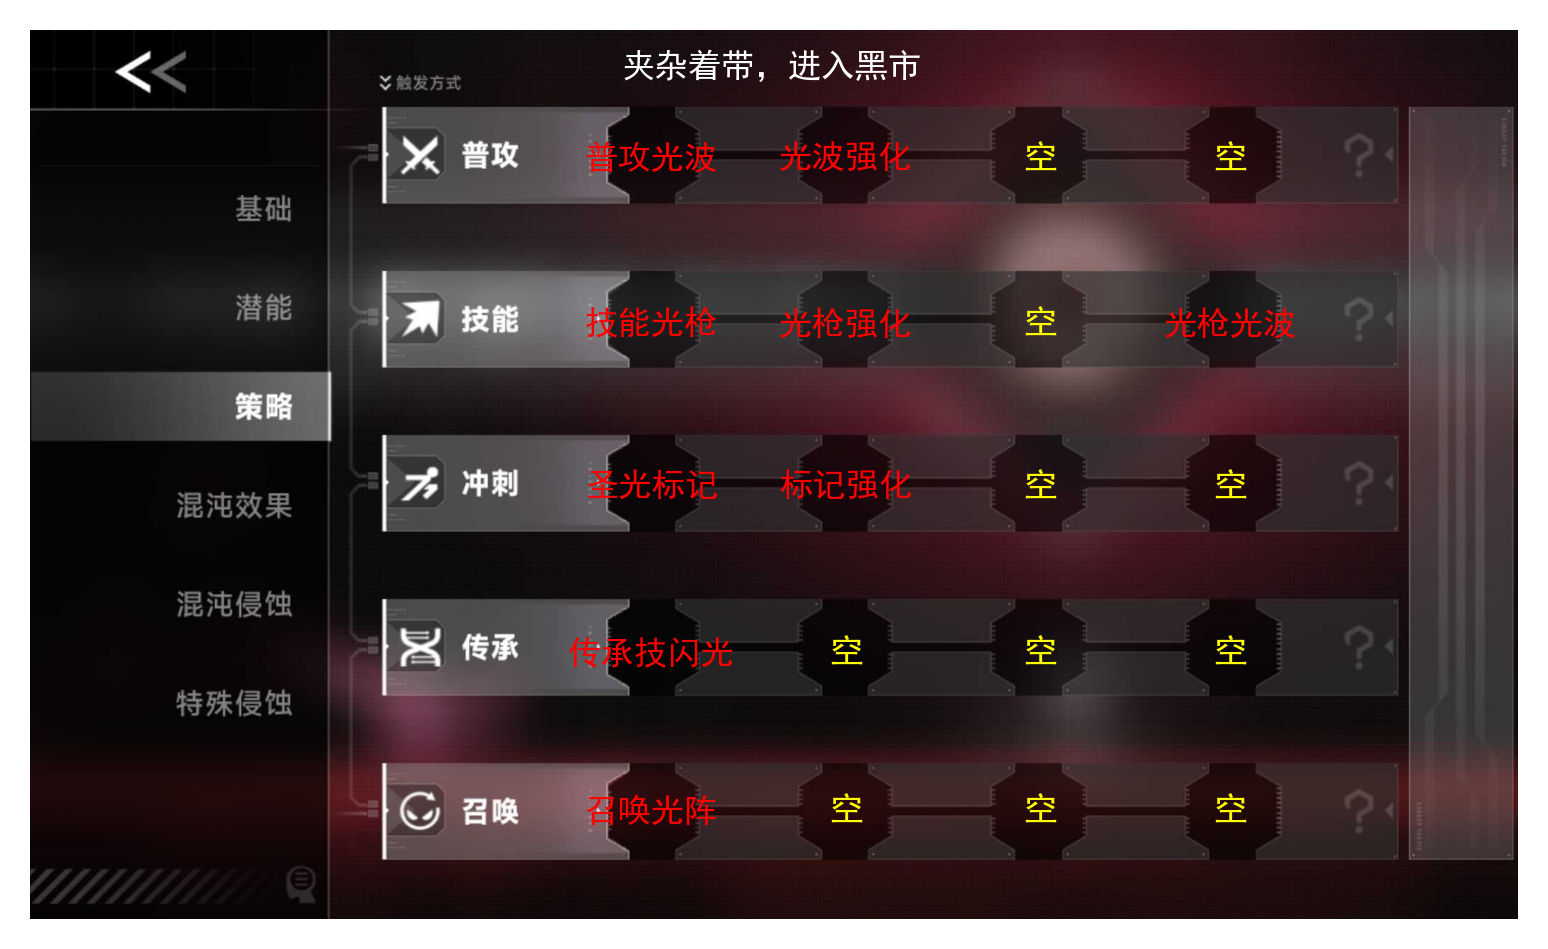

卡方统计量: 14.834146341463416, p 值: 0.13822659738617812
数据可能来自均匀分布或离散型概率分布
卡方统计量: 11.781961623436095, p 值: 0.2999140587169143
数据可能来自均匀分布或离散型概率分布
卡方统计量: 11.742397992758569, p 值: 0.30266677332985015
数据可能来自均匀分布或离散型概率分布
卡方统计量: 19.56456142357349, p 值: 0.03365086386514935
数据不太可能来自均匀分布或离散型概率分布。
卡方统计量: 10.217747845052076, p 值: 0.421601828982966
数据可能来自均匀分布或离散型概率分布


In [22]:
import verify_heishi

verify_heishi.fast_five('data/黑市房/黑市_2个一阶3个二阶.txt', [
    "增强光波",
    "光波传递, 至圣标记, 光波快充",
    "多重光枪",
    "标记共鸣",
    "标记闪光",
    "致盲延长",
    "闪光光枪, 持久光阵",
    "大型光阵",
    "光阵吸引",
    "闪光强化, 大范围闪光, 受击闪光",
    "光阵致盲, 光阵庇护, 光阵增幅",
], [1, 3, 1, 1, 1, 1, 2, 1, 1, 3, 3])


# 回归初始问题，直面马尔科夫链：全空进入黑市！

正常情况下，获得1个基础策略后，可解锁3个一阶强化，1个二阶强化，2个红策略。

异常情况下，冲刺燃烧对应4个一阶强化，基础寒冷无法解锁二阶强化和红策略，史莱姆的一阶强化和二阶强化会受影响，等等等。

第一抽策略池为全部基础策略，约有50种可能。

每种可能后，第二抽的策略池移除同触发位的基础策略，移除同派系的基础策略，加入一阶二阶红策略，大约还有50种可能。

每种可能后，第三抽同理，如果第二抽是基础策略，那么触发加入和移除；如果第二抽非基础策略，那么不触发加入和移除，粗略估计还有50种可能。

连续抽5次，共有 50的5次方 种情况，且每种情况的概率叠加情况都不一样，<font color='red'>其运算量已远超本人的编程水平和本人计算机的运算水平</font>

更要命的是，由于可能性达到大约 50**5， 而数据集只有少得可怜的250次，<font color='red'>绝大部分可能性都没有发生，无法验证</font>。

因此，由于数据量有限，只验证第一抽和第二抽，即便如此，面对高达50种情况，实际难度也非常高。

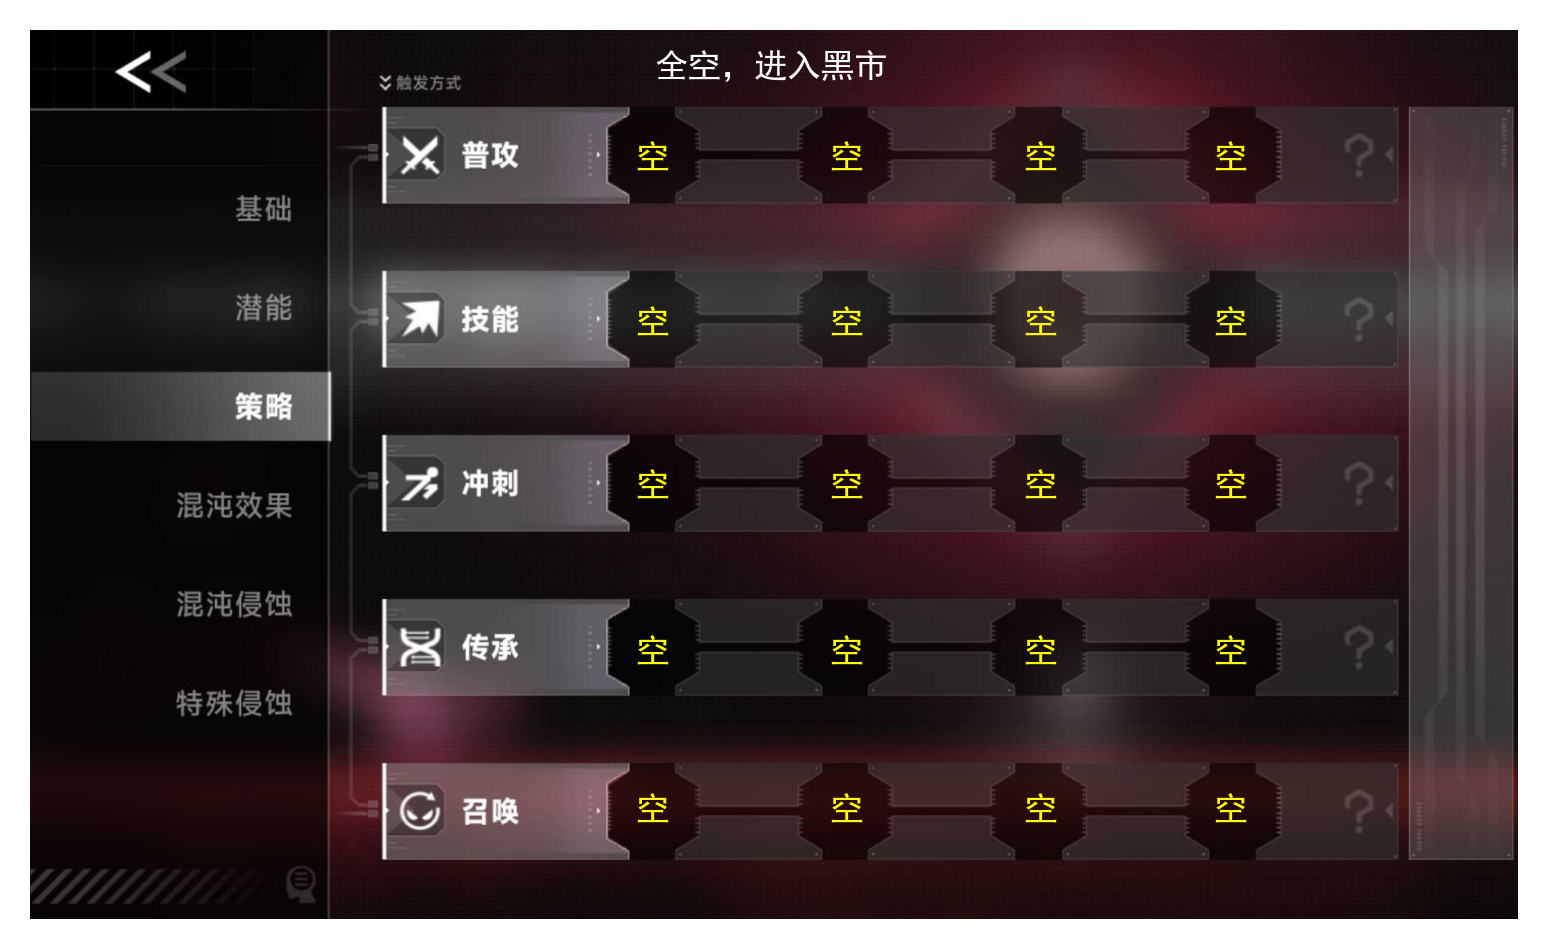

In [18]:
current_strategies, strategies = utils.parse_file('data/黑市房/黑市_全空.txt')
utils.draw_status("全空，进入黑市", current_strategies)

In [19]:
# 普攻光波为例，获得后：光波系冲突-0，普攻位冲突-7，一阶强化+3，二阶强化+1，红策略+1
# 记作：[-0, -7, 3, 1, 1]
# 技能光枪为例，获得后：光枪系冲突-1，技能位冲突-10，一阶强化+3，二阶强化+1，红策略+4
# 记作：[-1, -10, 3, 1, 4]

import database
from strategy import Strategy


def subclass_conflict(s: Strategy):
    return len([x for x in database.strategy_list if x.subclass == s.subclass and x.level == s.level]) - 1


def location_conflict(s: Strategy):
    return len([x for x in database.strategy_list if x.location == s.location and x.level == s.level]) - 1


for x in [x for x in database.strategy_list if x.level == 0 and x.location == '普攻']:
    print(f'"{x.name}": [-{subclass_conflict(x)}, -{location_conflict(x)}, 3, 1, {0}],')
for x in [x for x in database.strategy_list if x.level == 0 and x.location == '技能']:
    print(f'"{x.name}": [-{subclass_conflict(x)}, -{location_conflict(x)}, 3, 1, {0}],')
for x in [x for x in database.strategy_list if x.level == 0 and x.location == '冲刺']:
    print(f'"{x.name}": [-{subclass_conflict(x)}, -{location_conflict(x)}, 3, 1, {0}],')
for x in [x for x in database.strategy_list if x.level == 0 and x.location == '传承技']:
    print(f'"{x.name}": [-{subclass_conflict(x)}, -{location_conflict(x)}, 3, 1, {0}],')
for x in [x for x in database.strategy_list if x.level == 0 and x.location == '召唤']:
    print(f'"{x.name}": [-{subclass_conflict(x)}, -{location_conflict(x)}, 3, 1, {0}],')

"普攻撕裂": [-1, -7, 3, 1, 0],
"普攻影刺": [-1, -7, 3, 1, 0],
"普攻闪电": [-2, -7, 3, 1, 0],
"普攻燃烧": [-2, -7, 3, 1, 0],
"火精灵助战": [-0, -7, 3, 1, 0],
"普攻寒冷": [-1, -7, 3, 1, 0],
"普攻光波": [-0, -7, 3, 1, 0],
"普攻毒雾": [-1, -7, 3, 1, 0],
"技能撕裂": [-1, -10, 3, 1, 0],
"技能风暴": [-1, -10, 3, 1, 0],
"技能影刺": [-1, -10, 3, 1, 0],
"技能感电": [-1, -10, 3, 1, 0],
"技能闪电": [-2, -10, 3, 1, 0],
"技能燃烧": [-2, -10, 3, 1, 0],
"技能火弹": [-1, -10, 3, 1, 0],
"技能寒冷": [-1, -10, 3, 1, 0],
"技能光枪": [-1, -10, 3, 1, 0],
"技能毒环": [-1, -10, 3, 1, 0],
"技能毒液": [-1, -10, 3, 1, 0],
"冲刺飞剑": [-0, -6, 3, 1, 0],
"冲刺影子": [-0, -6, 3, 1, 0],
"冲刺落雷": [-0, -6, 3, 1, 0],
"冲刺燃烧": [-2, -6, 3, 1, 0],
"冲刺冰锥": [-1, -6, 3, 1, 0],
"圣光标记": [-0, -6, 3, 1, 0],
"冲刺毒弹": [-0, -6, 3, 1, 0],
"传承技风暴": [-1, -9, 3, 1, 0],
"传承技黑洞": [-0, -9, 3, 1, 0],
"传承技感电": [-1, -9, 3, 1, 0],
"电闪雷鸣": [-2, -9, 3, 1, 0],
"传承技火弹": [-1, -9, 3, 1, 0],
"传承技火环": [-0, -9, 3, 1, 0],
"传承技冰锥": [-1, -9, 3, 1, 0],
"传承技光枪": [-1, -9, 3, 1, 0],
"传承技闪光": [-0, -9, 3, 1, 0],
"传承技毒液": [-1, -9, 3, 1, 0],
"召唤刃环":

In [20]:
# 在脚本的基础上，修正一些一阶和二阶强化的数据，由于strategy里红策略有数据错误，因此红策略记为0
markov_transition_map = {
    "普攻撕裂": [-1, -7, 3, 1, 0],
    "普攻影刺": [-1, -7, 3, 1, 0],
    "普攻闪电": [-2, -7, 3, 1, 0],
    "普攻燃烧": [-2, -7, 3, 1, 0],
    "火精灵助战": [-0, -7, 3, 1, 0],
    "普攻寒冷": [-1, -7, 2, 0, 0],
    "普攻光波": [-0, -7, 3, 1, 0],
    "普攻毒雾": [-1, -7, 4, 1, 0],
    "技能撕裂": [-1, -10, 3, 1, 0],
    "技能风暴": [-1, -10, 4, 1, 0],
    "技能影刺": [-1, -10, 3, 1, 0],
    "技能感电": [-1, -10, 3, 1, 0],
    "技能闪电": [-2, -10, 3, 1, 0],
    "技能燃烧": [-2, -10, 3, 1, 0],
    "技能火弹": [-1, -10, 3, 1, 0],
    "技能寒冷": [-1, -10, 2, 0, 0],
    "技能光枪": [-1, -10, 3, 1, 0],
    "技能毒环": [-1, -10, 4, 1, 0],
    "技能毒液": [-1, -10, 3, 1, 0],
    "冲刺飞剑": [-0, -6, 3, 1, 0],
    "冲刺影子": [-0, -6, 3, 1, 0],
    "冲刺落雷": [-0, -6, 4, 1, 0],
    "冲刺燃烧": [-2, -6, 4, 1, 0],
    "冲刺冰锥": [-1, -6, 3, 1, 0],
    "圣光标记": [-0, -6, 3, 1, 0],
    "冲刺毒弹": [-0, -6, 3, 1, 0],
    "传承技风暴": [-1, -9, 4, 1, 0],
    "传承技黑洞": [-0, -9, 3, 1, 0],
    "传承技感电": [-1, -9, 3, 1, 0],
    "电闪雷鸣": [-2, -9, 3, 1, 0],
    "传承技火弹": [-1, -9, 3, 1, 0],
    "传承技火环": [-0, -9, 3, 1, 0],
    "传承技冰锥": [-1, -9, 3, 1, 0],
    "传承技光枪": [-1, -9, 3, 1, 0],
    "传承技闪光": [-0, -9, 3, 1, 0],
    "传承技毒液": [-1, -9, 3, 1, 0],
    "召唤刃环": [-0, -6, 4, 1, 0],
    "召唤触手": [-0, -6, 3, 1, 0],
    "环绕电球": [-0, -6, 3, 1, 0],
    "放置地雷": [-0, -6, 3, 1, 0],
    "召唤冰刺": [-0, -6, 3, 1, 0],
    "召唤光阵": [-0, -6, 3, 1, 0],
    "召唤史莱姆": [-0, -6, 2, 1, 0],
}

prob_start = [43, 0, 0, 0]
for k, v in markov_transition_map.items():
    prob_start[0] += v[0] / len(markov_transition_map)
    prob_start[0] += v[1] / len(markov_transition_map)
    prob_start[1] += v[2] / len(markov_transition_map)
    prob_start[2] += v[3] / len(markov_transition_map)
    prob_start[3] += v[4] / len(markov_transition_map)
prob_no_red = prob_start[0:3]
print(f"第二抽：基础/一阶/二阶的策略权重是 {prob_no_red=}")
prob_no_red = [x / sum(prob_no_red) for x in prob_no_red]
print(f"第二抽：基础/一阶/二阶的理论概率分布是 {prob_no_red=}")
print("卡方验证")
round_cnt = utils.to_level([x[1] for x in strategies])
round_cnt_no_red = round_cnt[0:3]
print("理论概率是", prob_no_red)
print("实际频率是", [x/sum(round_cnt_no_red) for x in round_cnt_no_red])
_ = utils.test_uniform_distribution(round_cnt_no_red, prob_no_red)

第二抽：基础/一阶/二阶的策略权重是 prob_no_red=[34.34883720930238, 3.0930232558139545, 0.9534883720930238]
第二抽：基础/一阶/二阶的理论概率分布是 prob_no_red=[0.8946093276801939, 0.0805572380375529, 0.024833434282253156]
卡方验证
理论概率是 [0.8946093276801939, 0.0805572380375529, 0.024833434282253156]
实际频率是 [0.826271186440678, 0.1440677966101695, 0.029661016949152543]
卡方统计量: 13.270247690349281, p 值: 0.001313416074843999
数据不太可能来自均匀分布或离散型概率分布。


虽然数据显示差异较大，但实际上差异不算特别大，可能是因为样本不足引起，个人认为可以接受

| 类别   | 理论概率（%） | 实际统计概率（%） | 差异（实际 - 理论） |
| ---- | ------- | --------- | ----------- |
| 类别 1 | 89.46   | 82.63     | -6.83       |
| 类别 2 | 8.06    | 14.41     | +6.35       |
| 类别 3 | 2.48    | 2.97      | +0.49       |


# 至此，黑市的理论研究就结束了。

# 苍翼扩展定律：黑马定律

黑（市）马（尔科夫）定律：简称黑马定律，黑市共进行五次抽取，每一抽都会等概率地从当前的可获得策略（可获得判定遵循黑市特有的规则）中抽取一个策略，从而构成马尔科夫链。

> 命名灵感来自和我一起玩苍翼的bobb